In [83]:
import opt_einsum as oe
import numpy as np
import torch
import sys
sys.path.append("../../")
import mps
from mps.trainer.data_utils import SyntheticDataset, SyntheticDatasetV2, SyntheticDatasetV3

In [84]:
N = 1000
dataset = SyntheticDatasetV3(n=N, num_samples=(2**25), seed=42)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=10, shuffle=True)

In [96]:
from mps.trainer.smps_trainer import smps_train
from mps.simple_mps import SimpleMPS
import copy
chi = 2
d = 2
l = 2
device = torch.device("cpu")
dtype = torch.float64
optimize = "greedy"
eps = 1 / N
smps = SimpleMPS(N, chi, d, l, layers=1, device=device, dtype=dtype, optimize=optimize, eps=eps, seed = 2)

logsoftmax = torch.nn.LogSoftmax(dim=-1)
nnloss = torch.nn.NLLLoss(reduction="mean")

Path is not set, setting...
Found the path
Initialized MPS with random matrices


In [97]:
data, target = next(iter(dataloader))

data_flipped = data.clone()
data_flipped[:, 0] = 1 - data_flipped[:, 0]  # Flip the first element in each data in the batch
target_flipped = 1 - target  # Flip the target

data = torch.cat((data, data_flipped), dim=0)
target = torch.cat((target, target_flipped), dim=0)

output = smps(data.permute(1, 0, 2))
ls = logsoftmax(output)
loss = nnloss(ls, target)

loss.backward()

In [98]:
# Convert target to a vector
target_flip = 1 - target
target_tensor = torch.stack((target, target_flip), dim=1)


In [99]:
A = torch.einsum("idj, nd, jl -> nil", smps.mps.params[-2], data[:, -1], smps.mps.params[-1])

for i in range(1, N - 1):
    A = torch.einsum("idj, nd, njk -> nik", smps.mps.params[-i - 2], data[:, -i - 1], A)



In [102]:
import opt_einsum as oe
import numpy as np
import torch
import sys
sys.path.append("../../")
import mps
from mps.trainer.data_utils import SyntheticDatasetV3
from mps.simple_mps import SimpleMPS
import matplotlib.pyplot as plt

# Fixed parameters for the model
chi = 2
d = 2
l = 2
device = torch.device("cpu")
dtype = torch.float64
optimize = "greedy"

# List of different system sizes to test
N_list = [10, 20, 40, 80, 160, 320, 400, 500, 600, 700, 800, 900, 1000]
# N_list = [10, 20, 40, 80, 160, 320, 400, ]
N_list = np.round(N_list).astype(int)
# N_list = [int(50 * (1.5 ** i for i in range(5)]
num_experiments = 400
# Batch size for data (can be adjusted as needed)
batch_size = 2**10

# Lists to store the averaged gradient statistics for each system size
avg_means = []
avg_vars = []

for N in N_list:
    print(N)
    experiment_means = []
    experiment_vars = []
    
    # Create a dataset for this system size (using a moderate number of samples)
    dataset = SyntheticDatasetV3(n=N, num_samples=2**15, seed=42)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    # Get one batch of data and labels
    data, target = next(iter(dataloader))
    
    # Increase the data
    data_flipped = data.clone()
    data_flipped[:, 0] = 1 - data_flipped[:, 0]  # Flip the first element in each data in the batch
    target_flipped = 1 - target  # Flip the target
    
    # Concatenate the original and flipped data and targets
    data = torch.cat((data, data_flipped), dim=0)
    target = torch.cat((target, target_flipped), dim=0)
    
    # Run several experiments to average out the gradient behavior
    for exp in range(num_experiments):
        # For each experiment, create a fresh model.
        # Here, eps is chosen as 1/N, similar to your original code.
        eps = 1 / N
        seed = np.random.randint(0, 1000000)
        smps = SimpleMPS(N, chi, d, l, layers=1, device=device, dtype=dtype, optimize=optimize, eps=eps, seed=seed)
        
        # Forward pass (note the permutation as in your code)
        output = smps(data.permute(1, 0, 2))
        
        # Compute the loss (using LogSoftmax and NLLLoss as before)
        logsoftmax = torch.nn.LogSoftmax(dim=-1)
        nnloss = torch.nn.NLLLoss(reduction="mean")
        ls = logsoftmax(output)
        loss = nnloss(ls, target)
        
        # Backward pass to compute gradients
        loss.backward()
        
        # Extract the gradient for the parameter of interest.
        # Here, we choose the parameter at index -2 (as in your snippet).
        grad_param = smps.mps.params[-2].grad
        
        # Calculate mean and variance over all gradient matrix elements.
        mean_grad = grad_param.norm()
        var_grad = grad_param.var().item()
        
        experiment_means.append(mean_grad)
        experiment_vars.append(var_grad)
    
    # Average the gradient statistics over the experiments for this system size.
    avg_means.append(np.mean(experiment_means))
    avg_vars.append(np.mean(experiment_vars))
    


10
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the path
Initialized MPS with random matrices
Path is not set, setting...
Found the

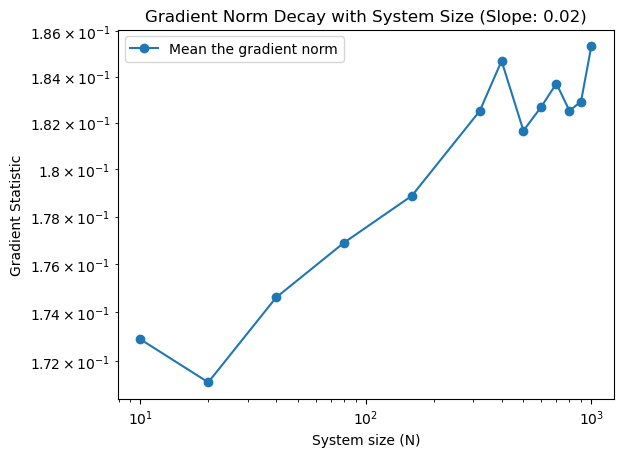

In [103]:
# Perform a linear fit on the log-log scale data
log_N_list = np.log(N_list)
log_avg_means = np.log(avg_means)
slope, intercept = np.polyfit(log_N_list, log_avg_means, 1)

# Plot both the mean and variance vs system size in a log-log scale.
plt.figure()
plt.loglog(N_list, avg_means, marker='o', label='Mean the gradient norm')
plt.xlabel("System size (N)")
plt.ylabel("Gradient Statistic")
plt.title(f"Gradient Norm Decay with System Size (Slope: {slope:.2f})")
plt.legend()
plt.show()

In [107]:
avg_means

[0.007832246877776823,
 0.0017804839524512553,
 0.00045537683812085544,
 0.0001284089297661758,
 3.0654468324806414e-05,
 6.498132566744372e-06,
 5.184168183931711e-06,
 2.811898510601469e-06,
 2.1091837073296406e-06,
 1.5606574421166404e-06,
 1.040615567388813e-06,
 9.279358637799916e-07,
 7.230532643596027e-07]